<a href="https://colab.research.google.com/github/fredd-a/Intro-to-AI-Project/blob/main/notebooks/02_baseline_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#2.0 Setup & Loading Cleaned Data

---

In [1]:
# Import neccesary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Load cleaned data from github, "Intro-to-AI-Project/data/processed"
github_url = "https://raw.githubusercontent.com/fredd-a/Intro-to-AI-Project/main/data/processed/student_performance_cleaned.csv"

df = pd.read_csv(github_url)

# Verify that the cleaned dataset loaded successfully
print("Dataset shape:", df.shape)

# View first rows
df.head(10)

Dataset shape: (960, 9)


,StudentID,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,Online Classes Taken
0,1,Male,85.0,15.0,78.0,1.0,High,80.0,False
1,2,Female,90.0,20.0,85.0,2.0,Medium,87.0,True
2,3,Male,78.0,10.0,65.0,0.0,Low,68.0,False
3,4,Male,92.0,25.0,90.0,3.0,High,92.0,False
4,5,Female,88.0,18.0,82.0,2.0,Medium,85.0,True
5,6,Female,95.0,30.0,88.0,1.0,High,80.0,False
6,7,Male,70.0,8.0,60.0,0.0,Low,62.0,False
7,8,Female,88.0,17.0,77.0,1.0,Medium,78.0,True
8,9,Male,82.0,12.0,70.0,2.0,Low,72.0,False
9,10,Female,91.0,22.0,86.0,3.0,High,88.0,True


#2.1 Defining Risk Categories

---



In [2]:
df["FinalGrade"].describe()

,FinalGrade
count,960.00000
mean,80.12500
std,9.32313
min,62.00000
25%,72.00000
50%,80.00000
75%,88.00000
max,92.00000


## Creating Risk Categories

The original FinalGrade variable is converted into three classes:

- High Risk: Grade below 75
- Medium Risk: Grade between 75 and 84
- Low Risk: Grade 85 and above

These categories allow us to treat the problem as a classification task.

In [3]:
# Implement the classification targets from final grade (low,medium,high risk)
def classify_risk(grade):
    if grade < 75:
        return "High Risk"
    elif grade < 85:
        return "Medium Risk"
    else:
        return "Low Risk"


df["RiskCategory"] = df["FinalGrade"].apply(classify_risk)


df[["FinalGrade", "RiskCategory"]].head()

,FinalGrade,RiskCategory
0,80.0,Medium Risk
1,87.0,Low Risk
2,68.0,High Risk
3,92.0,Low Risk
4,85.0,Low Risk


In [4]:
# Examine the distribution of the target classes before training
df["RiskCategory"].value_counts()


,count
RiskCategory,
Low Risk,448
High Risk,275
Medium Risk,237


In [5]:
df["RiskCategory"].value_counts(normalize=True)*100

,proportion
RiskCategory,
Low Risk,46.666667
High Risk,28.645833
Medium Risk,24.687500


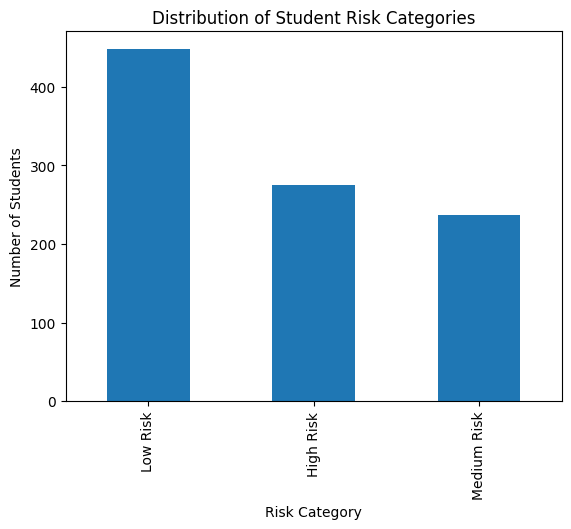

In [6]:
df["RiskCategory"].value_counts().plot(
    kind="bar",
    xlabel="Risk Category",
    ylabel="Number of Students",
    title="Distribution of Student Risk Categories"
)

plt.show()

The target variable was created from FinalGrade by grouping students into three academic risk categories. Students with grades below 75 were classified as High Risk, grades between 75 and 84 as Medium Risk, and grades of 85 or above as Low Risk. These thresholds were selected based on the dataset distribution, where the minimum grade was 62 and the median grade was 80. This ensures that all three categories contain sufficient examples for classification.

# 2.2 Feature Selection & Encoding

---



In [7]:
# Inspect the dataset before feature selection and encoding
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 960 entries, 0 to 959
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   StudentID                  960 non-null    int64  
 1   Gender                     960 non-null    object 
 2   AttendanceRate             960 non-null    float64
 3   StudyHoursPerWeek          960 non-null    float64
 4   PreviousGrade              960 non-null    float64
 5   ExtracurricularActivities  960 non-null    float64
 6   ParentalSupport            960 non-null    object 
 7   FinalGrade                 960 non-null    float64
 8   Online Classes Taken       960 non-null    bool   
 9   RiskCategory               960 non-null    object 
dtypes: bool(1), float64(5), int64(1), object(3)
memory usage: 68.6+ KB


# Separate predictor variables (X) from the target variable (y)

In [8]:

# Separate input features and prediction target

X = df.drop(columns=["StudentID", "FinalGrade", "RiskCategory"])

y = df["RiskCategory"]

print("Features:")
display(X.head())

print("\nTarget:")
display(y.head(10))

Features:


,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,Online Classes Taken
0,Male,85.0,15.0,78.0,1.0,High,False
1,Female,90.0,20.0,85.0,2.0,Medium,True
2,Male,78.0,10.0,65.0,0.0,Low,False
3,Male,92.0,25.0,90.0,3.0,High,False
4,Female,88.0,18.0,82.0,2.0,Medium,True



Target:


,RiskCategory
0,Medium Risk
1,Low Risk
2,High Risk
3,Low Risk
4,Low Risk
5,Medium Risk
6,High Risk
7,Medium Risk
8,High Risk
9,Low Risk


#Encode Gender

Gender is a categorical variable with two possible values: Male and Female.

Since these categories do not have any natural order or ranking, binary encoding is appropriate:
- Male → 1
- Female → 0

In [9]:
gender_map = {
    "Male": 1,
    "Female": 0
}

X["Gender"] = X["Gender"].map(gender_map)

### Online Classes Taken Encoding

Online Classes Taken is a binary variable representing whether a student participated in online classes.

False = 0  
True = 1

In [10]:
X["Online Classes Taken"] = X["Online Classes Taken"].astype(int)

### Parental Support Encoding

ParentalSupport is an ordinal variable because the categories have a meaningful order.

Low = 0  
Medium = 1  
High = 2

Ordinal encoding preserves this relationship.

In [11]:
support_map = {
    "Low": 0,
    "Medium": 1,
    "High": 2
}

X["ParentalSupport"] = X["ParentalSupport"].map(support_map)

# Verify that all categorical features have been encoded correctly

In [12]:
X.head()

,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,Online Classes Taken
0,1,85.0,15.0,78.0,1.0,2,0
1,0,90.0,20.0,85.0,2.0,1,1
2,1,78.0,10.0,65.0,0.0,0,0
3,1,92.0,25.0,90.0,3.0,2,0
4,0,88.0,18.0,82.0,2.0,1,1


Encoding Decisions

Categorical variables were converted into numerical representations because machine learning algorithms require numerical inputs.



Gender: Binary encoding was used because Gender contains two categories without any natural ordering (Male/Female).
Online Classes Taken: Binary encoding was applied because it represents a yes/no condition.
ParentalSupport: Ordinal encoding was used because the categories have a meaningful ranking: Low, Medium, and High. Assigning numerical values preserves this relationship.



At this stage, the dataset has been cleaned, the target variable has been defined, categorical variables have been encoded, and the feature matrix is ready for model training. The next step is to split the data into training and testing sets.

#2.3 Train/Test Split

---



# Inspect the dataset before spliting

In [13]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 960 entries, 0 to 959
Data columns (total 7 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Gender                     960 non-null    int64  
 1   AttendanceRate             960 non-null    float64
 2   StudyHoursPerWeek          960 non-null    float64
 3   PreviousGrade              960 non-null    float64
 4   ExtracurricularActivities  960 non-null    float64
 5   ParentalSupport            960 non-null    int64  
 6   Online Classes Taken       960 non-null    int64  
dtypes: float64(4), int64(3)
memory usage: 52.6 KB


#Perform the stratified split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

#Checking the sizes

In [15]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (768, 7)
X_test shape: (192, 7)
y_train shape: (768,)
y_test shape: (192,)


#Confirming class balance

In [16]:
print("Original Dataset:")
print(y.value_counts(normalize=True) * 100)

Original Dataset:
RiskCategory
Low Risk       46.666667
High Risk      28.645833
Medium Risk    24.687500
Name: proportion, dtype: float64


#Check training set:

In [17]:
print("\nTraining Set:")
print(y_train.value_counts(normalize=True) * 100)


Training Set:
RiskCategory
Low Risk       46.614583
High Risk      28.645833
Medium Risk    24.739583
Name: proportion, dtype: float64


#Check testing set:

In [18]:
print("\nTesting Set:")
print(y_test.value_counts(normalize=True) * 100)


Testing Set:
RiskCategory
Low Risk       46.875000
High Risk      28.645833
Medium Risk    24.479167
Name: proportion, dtype: float64


### Train/Test Split

The dataset was divided into training and testing sets using an 80/20 split. Since the target variable contains multiple risk categories, stratified sampling was applied to preserve the proportion of High Risk, Medium Risk, and Low Risk students in both sets.

This prevents class imbalance between training and testing data and ensures that the model evaluation represents the original dataset distribution.

In [19]:
# Stratified split (since it's classification) on the risk-category target.
# Print resulting sizes and confirm class balance is preserved in both sets.

#2.4 Baseline Comparator

---



In [21]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

# A dumb baseline (e.g. always predict the majority class)
dumb_base = DummyClassifier(strategy="most_frequent", random_state = 42)

# Fit the dumb baseline on the training data
dumb_base.fit(X_train, y_train)

# Establishes the floor Random Forest needs to beat.
base_pred = dumb_base.predict(X_test)
base_acc = accuracy_score(y_test, base_pred)

# Report its accuracy.
print("Baseline Accuracy:", base_acc)

Baseline Accuracy: 0.46875


#2.5 Random Forest Classifier (Main Model)

---



In [28]:
from sklearn.ensemble import RandomForestClassifier
# Fit RandomForestClassifier with random_state set and modest constraints (max_depth,min_samples_leaf) given the dataset size
randomf_clf = RandomForestClassifier(n_estimators=200,max_depth=6,min_samples_leaf=5,random_state=42)
randomf_clf.fit(X_train, y_train)

# Print basic fit confirmation
print("Train Accuracy: ", randomf_clf.score(X_train, y_train))
print("Test Accuracy: ", randomf_clf.score(X_test, y_test))

Train Accuracy:  0.5299479166666666
Test Accuracy:  0.46875


This Random Forest Classifier was trained using 200 trees to ensure a stabe and average prediction.

Two constraints(max_dept = 6, min_samples_leaf = 5) were used to prevent overfitting, given the size of the dataset.
These constraints were applied because after testing with an unconstrained version, train accuracy was 99% while test accuracy was 39%, showing that it was fitting noise.

The constrainted model has a train accuracy of 53% and test accuracy of 47%, indicating there is no overfitting, but its overall accuracy is still limited by weak signal in the underlying features.

#2.6 Evaluating the Classifier

---



Accuracy: 0.46875
              precision    recall  f1-score   support

   High Risk       0.33      0.02      0.03        55
    Low Risk       0.48      0.98      0.64        90
 Medium Risk       0.25      0.02      0.04        47

    accuracy                           0.47       192
   macro avg       0.35      0.34      0.24       192
weighted avg       0.38      0.47      0.32       192



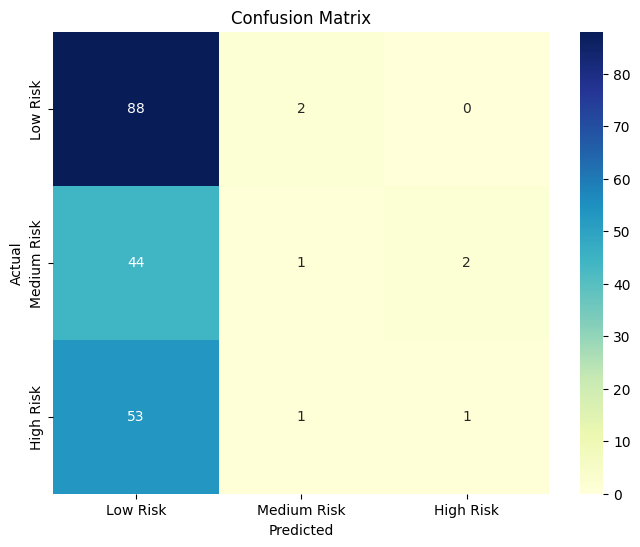

In [31]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Make predictions on the test set
y_pred = randomf_clf.predict(X_test)

# Accuracy, precision/recall/F1 (per class)
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)
print(classification_report(y_test, y_pred))

# Confusion Matrix
labels = ["Low Risk", "Medium Risk", "High Risk"]
conf_matrix = confusion_matrix(y_test, y_pred, labels=labels)

fig,ax = plt.subplots(figsize=(8,6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="YlGnBu", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
ax.set_title("Confusion Matrix")
plt.show()

**Why Precission/Recall Matter More Than Accuracy**

Overall accuracy (47%) looks reasonable at first glance, but the per-class breakdown reveals a critical failure: High Risk recall is only 0.02, meaning the model correctly identified just 1 of 55 truly high-risk students in the test set, with Medium Risk recall equally low at 0.02, while Low Risk recall sits at 0.98.

The model is essentially predicting "Low Risk" for almost every student regardless of their actual attendance, study habits, or prior grades.


#2.7 Feature Importance (Classifier)

---



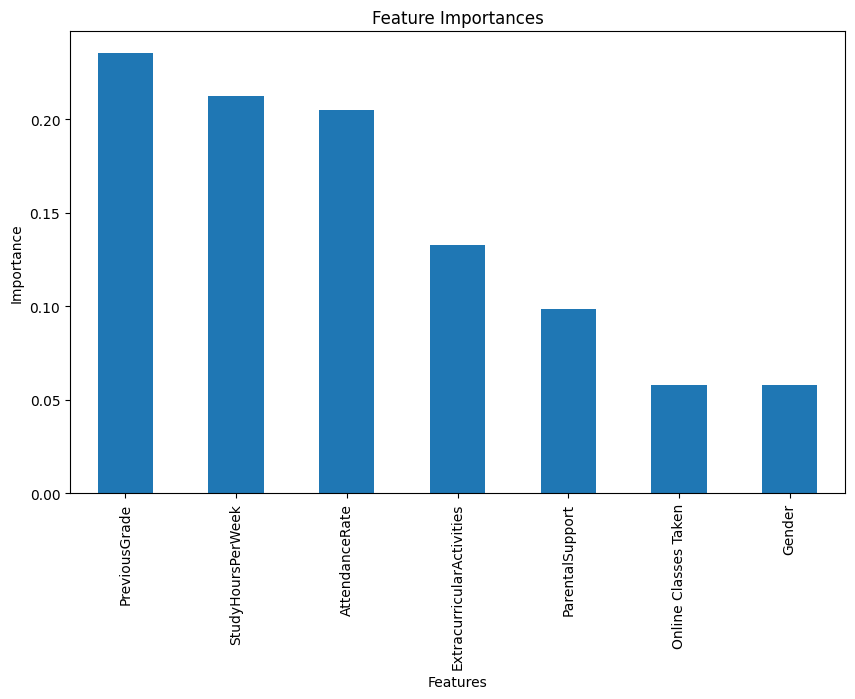

In [34]:
import pandas as pd
# Plot importances
importances = pd.Series(randomf_clf.feature_importances_, index=X_train.columns)

# Sort the importances in descending order
importances = importances.sort_values(ascending=False)

# Plot the feature importances
fig, ax = plt.subplots(figsize=(10, 6))
importances.plot(kind='bar', figsize=(10, 6))
ax.set_xlabel('Features')
ax.set_ylabel('Importance')
ax.set_title('Feature Importances')

plt.show()
# Reasoning cell interpreting results — flag PreviousGrade dominance if it appears

# Note where Online Classes Taken lands relative to your EDA finding.
# (Explanation) During the data cleaning I found that for 'OnlineClassesTaken' there was no difference in
# final grade between those marked true and those marked false, how does what I found compare with what you find here.

Feature importance shows a relatively even spread across PreviousGrade (0.235), StudyHoursPerWeek (0.213), and AttendanceRate (0.205), with ExtracurricularActivities and ParentalSupport contributing moderately, and Online Classes Taken and Gender ranking lowest at 0.058 each.

feature importance measures how often a feature was useful for splitting the data during training, not whether that split led to a genuinely correct prediction, so a relatively even spread here does not contradict the model's weak predictive performance in 2.6

The low importance of Online Classes Taken is consistent with the EDA finding that this feature showed no meaningful difference in FinalGrade between students who did and did not take online classes, suggesting the model correctly deprioritized a feature with little real relationship to the outcome, even while its overall classification performance remained weak.

#2.8 Random Forest Regressor (Secondary Model)

---



In [ ]:
# Same features, same split logic, but predicting raw FinalGrade.

# The main model (2.5) gives results in terms of classification, (e.g high risk, medium risk)
# This model is supplementary to that and gives us the prediction of the final grade
# Brief reasoning cell framing this as supplementary detail alongside the classification result, not the headline.

#2.9 Evaluating the Regressor

---



In [ ]:
# RMSE, MAE, R². Optional: predicted vs. actual scatter plot.

#2.10 Summary & Next Steps
---

In [ ]:
# Markdown cell tying it together: baseline vs Random Forest comparison, key findings
# What's due for Week 12